In [ ]:
#| default_exp prototypical_ex

In [ ]:
#| hide

import plotly.io as pio

In [ ]:
#| hide
pio.renderers.default = "png"

# Denoising Variational Auto-Encoder

In [ ]:
#| eval: false
from fhemb.utils.cutils import prepare_data, split_scale_data

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
2026-04-24 00:17:09.945018: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.paths
DEBUG:fhemb.config.s

In [ ]:
#| eval: false
from nbdev_fhemb.wreconstruction_ex import emb_prj_decomp_rec1

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=[(40, 44), (47, 52), 53, 54, (56, 71), (73, 75)], args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75] and args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75]
 [DEBUG] piece.__init__: Compact numeric subjects: [(40, 44), (47, 54), (56, 71), (73, 75)]
 [INFO] piece._load_from_db: Loading face_t fro

In [ ]:
#| eval: false
X_all=emb_prj_decomp_rec1.get_df_ts_subjs('p80')['percentiles_ts'] 

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p80
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features p80
 [DEBUG] embedding.get_ts_subjs: Available features: ('p20', 'p80')
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p80
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features p80
 [DEBUG] embedding.get_ts_subjs: Available features: ('bh1', 'bh2', 'bh3')
 [WARNING] embedding.get_ts_subjs_ftr: Feature p80 not in features: ('bh1', 'bh2', 'bh3')
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p80
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features p80
 [DEBUG] embedding.get_ts_subjs: Available features: ('pc0', 'pc1', 'pc2')
 [WARNING] embedding.get_ts_subjs_ftr: Feature p80 not in features: ('pc0', 'pc1

In [ ]:
#| eval: false
X_all.shape  # (n_timesteps x n_subjects)

(1000, 32)

In [ ]:
#| eval: false

X, y = prepare_data(   # prepare the matrix X and label vector y for the two groups
    X_all[:250].T,     # first 250 samples for group 0 and transpose to (n_subjects x n_timesteps)
    X_all[750:].T      # last 250 samples for group 1 and transpose to (n_subjects x n_timesteps)
)

In [ ]:
#| eval: false
X.shape  # 64 10-dimensional time series 

(64, 250)

In [ ]:
#| eval: false

X_train, X_test, y_train, y_test, _ = split_scale_data(
    X,
    y,
    test_size=0.3,
    random_state=42,
    normalize='minmax',
)

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
#| hide
#| eval: false

X_train.shape, X_test.shape

((44, 250, 1), (20, 250, 1))

In [ ]:
#| eval: false
!pip install dvae

In [ ]:
#| eval: false
from dvae.classifier import VAEClassifier

Is cuda available? False
Cuda device count: 0
Using device: cpu
Pyro version: 1.9.1


/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#| eval: false
clf = VAEClassifier(
    feature_dim=250,
    z_dim=80,
    hidden_dim=80,
    alpha1=1e-5,
    alpha2=1,
    beta=1e-2,
    corruption=0.0,
    seed=42,
)

In [ ]:
#| eval: false
clf.fit(X_train.squeeze(), y_train.squeeze(), num_epochs=1000)

 [WARNING] src.utils.logger._propose_threshold: Multiple best accuracies: [0.5        0.5        0.5        0.5        0.5        0.5
 0.5        0.90909091 0.90909091 0.90909091 0.90909091 0.90909091
 0.90909091 0.5        0.5        0.5        0.5        0.5       ]


,feature_dim,250


In [ ]:
#| eval: false

y_pred = clf.predict(X_test.squeeze())

In [ ]:
#| eval: false
from fhemb.utils.cutils import calc_similarity

In [ ]:
#| eval: false
calc_similarity(y_test, y_pred, sim_metric='f1')

0.898989898989899

In [ ]:
#| eval: false
calc_similarity(y_test, y_pred, sim_metric='accuracy')

0.9

In [ ]:
#| eval: false
clf2 = VAEClassifier(
    feature_dim=250,
    z_dim=80,
    hidden_dim=80,
    alpha1=1e-5,
    alpha2=1,
    beta=1e-2,
    corruption=0.0,
    seed=42,
)

In [ ]:
#| eval: false
y2_pred = clf.fit_predict_on(X_train.squeeze(), y_train.squeeze(), X_test.squeeze(), num_epochs=1000)

 [WARNING] src.utils.logger._propose_threshold: Multiple best accuracies: [0.5        0.5        0.5        0.5        0.5        0.97727273
 1.         1.         1.         0.93181818 0.90909091 0.88636364
 0.63636364 0.5        0.5        0.5        0.5        0.5       ]


In [ ]:
#| eval: false
calc_similarity(y_test, y2_pred, sim_metric='f1')

0.849624060150376

In [ ]:
#| eval: false
calc_similarity(y_test, y2_pred, sim_metric='accuracy')

0.85

In [ ]:
#| eval: false
z_all = clf.vae.z_loc_embedding

In [ ]:
#| eval: false
z_all[y_test==0]

(10, 80)

In [ ]:
#| eval: false
from fhemb.utils.cutils import plot_dm_projection

 [DEBUG] cutils.calc_distance_matrix: Computing DTW distance matrix for symmetric data
Computing DTW distances: 100%|██████████| 210/210 [00:00<00:00, 866.53it/s]
 [WARNING] cutils.plot_dm_projection: PCA assumes a feature matrix, not a distance matrix. Consider using MDS or TSNE for distance-based projections.


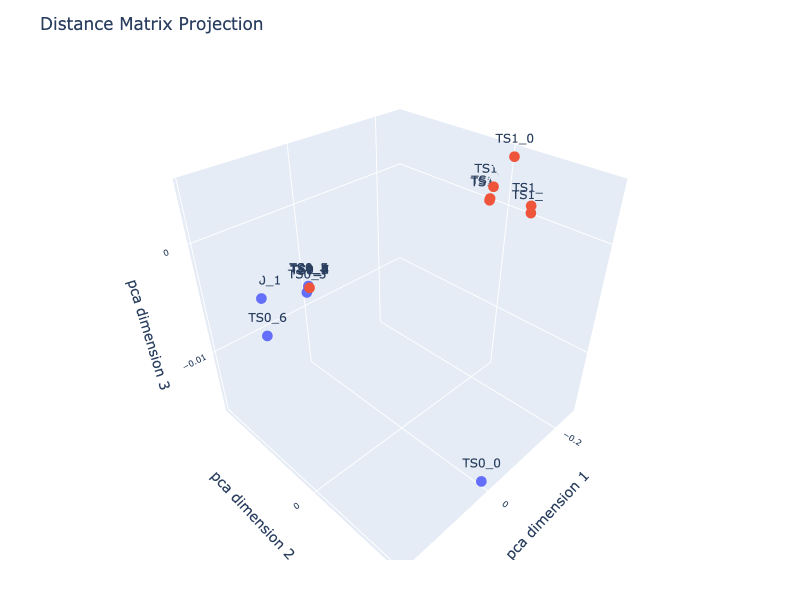

In [ ]:
#| eval: false

plot_dm_projection(
    z_all[y_test==0],
    z_all[y_test==1],           # data matrices for two groups 
    alignment_type='dcor',      # distance correlation by Székely, Rizzo, and Bakirov (2007)            
    projection='pca',           # projection method for dimensionality reduction ('pca', 'tsne', 'mds') 
    transformation='minmax',    # to transform distances into similarities for PCA
    normalize='l1',             # normalization method for distance matrix
    n_jobs=8,                   # number of jobs for parallelization
    dimensions=3,               # number of dimensions of the projection
) 

In [ ]:
#| eval: false

!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [umap-learn]2 [umap-learn]


In [ ]:
#| eval: false

from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.decomposition import PCA

In [ ]:
#| eval: false

umap=UMAP(n_components=3, random_state=0)
reduced_umap=umap.fit_transform(z_all)

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
#| eval: false
import matplotlib.pyplot as plt

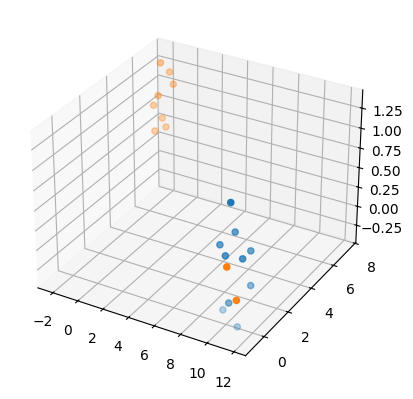

In [ ]:
#| eval: false

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')


ax.scatter(reduced_umap[y_test==0, 0], reduced_umap[y_test==0, 1], reduced_umap[y_test==0, 2])
ax.scatter(reduced_umap[y_test==1, 0], reduced_umap[y_test==1, 1], reduced_umap[y_test==1, 2])
plt.show()


In [ ]:
#| eval: false

pca=PCA(n_components=3, random_state=0)
reduced_pca=pca.fit_transform(z_all)

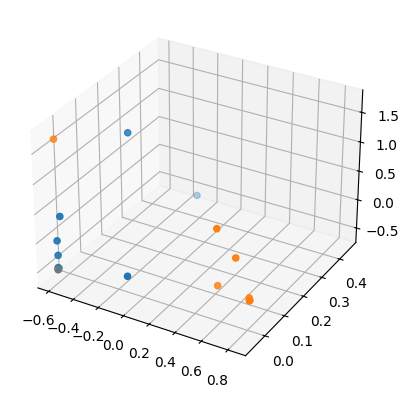

In [ ]:
#| eval: false

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')


ax.scatter(reduced_pca[y_test==0, 0], reduced_pca[y_test==0, 1], reduced_pca[y_test==0, 2])
ax.scatter(reduced_pca[y_test==1, 0], reduced_pca[y_test==1, 1], reduced_pca[y_test==1, 2])
plt.show()